In [364]:
!rm -rf sample_data/ *.png

In [365]:
!pip install yahoo_fin requests-html

In [366]:
import os
from datetime import datetime, timedelta
import requests
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [367]:
ticker = "TSLA"
end_date = datetime.now()
start_date = end_date - timedelta(days=5380) # 5380 days since June 29, 2010

In [368]:
tesla_data = yf.download(ticker, start=start_date, end=end_date)
print('\n')
print(tesla_data.head())

[*********************100%***********************]  1 of 1 completed



Price          Close      High       Low      Open     Volume
Ticker          TSLA      TSLA      TSLA      TSLA       TSLA
Date                                                         
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500
2010-07-07  1.053333  1.108667  0.998667  1.093333  103825500
2010-07-08  1.164000  1.168000  1.038000  1.076000  115671000


In [369]:
new_tesla_df = pd.DataFrame()

for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    new_tesla_df[col] = tesla_data[(col, 'TSLA')]

new_tesla_df = new_tesla_df.reset_index()
new_tesla_df = new_tesla_df.rename(columns={'index': 'Date'})

cols = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
new_tesla_df = new_tesla_df[cols]

print(new_tesla_df.head())
tesla_df = new_tesla_df

        Date     Close      High       Low      Open     Volume
0 2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
1 2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
2 2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500
3 2010-07-07  1.053333  1.108667  0.998667  1.093333  103825500
4 2010-07-08  1.164000  1.168000  1.038000  1.076000  115671000


In [370]:
print(f'Columns: {tesla_df.columns.tolist()}')
print(f'Rows: {len(tesla_df)}')

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
Rows: 3704


In [371]:
def prepare_data(df, forecast_period=5):
    df = df.copy()

    df['Future_Close'] = df['Close'].shift(-forecast_period)
    df['Price_Change_Pct'] = ((df['Future_Close'] - df['Close']) / df['Close']) * 100
    df['Target'] = 0  # 0 for hold

    threshold = 0.01  # 1% change threshold

    df.loc[df['Future_Close'] > df['Close'] * (1 + threshold), 'Target'] = 1  # 1 for buy
    df.loc[df['Future_Close'] < df['Close'] * (1 - threshold), 'Target'] = 2  # 2 for sell

    df = df.dropna()

    return df

In [372]:
def create_features(df, window_sizes=[5, 10, 20, 50]):
    df = df.copy()

    for window in window_sizes:
        df[f'SMA_{window}'] = df['Close'].rolling(window=window).mean()
        df[f'STD_{window}'] = df['Close'].rolling(window=window).std()

        df[f'RSI_{window}'] = calculate_rsi(df['Close'], window)

        df[f'Upper_Band_{window}'] = df[f'SMA_{window}'] + (df[f'STD_{window}'] * 2)
        df[f'Lower_Band_{window}'] = df[f'SMA_{window}'] - (df[f'STD_{window}'] * 2)

        df[f'Distance_Upper_Band_{window}'] = (df['Close'] - df[f'Upper_Band_{window}']) / df[f'Upper_Band_{window}']
        df[f'Distance_Lower_Band_{window}'] = (df['Close'] - df[f'Lower_Band_{window}']) / df[f'Lower_Band_{window}']

        df[f'Return_{window}'] = df['Close'].pct_change(window)

        df[f'Volume_Change_{window}'] = df['Volume'].pct_change(window)

    df['Daily_Return'] = df['Close'].pct_change()
    df['Volume_Change'] = df['Volume'].pct_change()
    df['High_Low_Diff'] = (df['High'] - df['Low']) / df['Low']
    df['Open_Close_Diff'] = (df['Close'] - df['Open']) / df['Open']

    return df.dropna()


In [373]:
def calculate_rsi(prices, window=14):
    delta = prices.diff()
    up = delta.copy()
    up[up < 0] = 0
    down = -1 * delta.copy()
    down[down < 0] = 0

    avg_gain = up.rolling(window).mean()
    avg_loss = down.rolling(window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

In [374]:
def make_prediction_with_explanation(model, df, date_str, forecast_period=5):
    try:
        date = pd.to_datetime(date_str)

        if date not in df['Date'].values:
            closest_date = df['Date'][df['Date'] <= date].max()
            if pd.isna(closest_date):
                return "Date is before available data. Using earliest available date."
            date = closest_date

        date_index = df[df['Date'] == date].index[0]

        current_row = df.loc[date_index]
        current_price = current_row['Close']

        future_date_index = date_index + forecast_period
        future_price = None
        price_change_pct = None

        if future_date_index < len(df):
            future_price = df.loc[future_date_index, 'Close']
            price_change_pct = ((future_price - current_price) / current_price) * 100

        features = df.drop(['Date', 'Future_Close', 'Price_Change_Pct', 'Target', 'Open', 'High', 'Low', 'Close', 'Volume'], axis=1)
        X = features.loc[date_index:date_index]

        prediction = model.predict(X)[0]
        proba = model.predict_proba(X)[0]
        confidence = proba[prediction] * 100

        action_map = {0: "HOLD", 1: "BUY", 2: "SELL"}
        action = action_map[prediction]

        feature_importances = model.feature_importances_
        features_sorted = sorted(zip(features.columns, feature_importances), key=lambda x: x[1], reverse=True)
        key_indicators = {feat: importance for feat, importance in features_sorted[:5]}

        rsi_value = current_row.get('RSI_14', None)
        sma_short = current_row.get('SMA_5', None)
        sma_long = current_row.get('SMA_20', None)

        explanation = {
            'action': action,
            'confidence': confidence,
            'current_price': current_price,
            'date': date_str,
            'future_price': future_price,
            'price_change_pct': price_change_pct,
            'key_indicators': key_indicators,
            'technical_indicators': {
                'RSI': rsi_value,
                'SMA_5': sma_short,
                'SMA_20': sma_long
            }
        }

        return explanation

    except Exception as e:
        return f"Error making prediction: {str(e)}"

In [375]:
def format_prediction_output(prediction_result):
    if isinstance(prediction_result, str):
        return prediction_result

    action = prediction_result['action']
    confidence = prediction_result['confidence']
    current_price = prediction_result['current_price']
    date = prediction_result['date']
    future_price = prediction_result['future_price']
    price_change_pct = prediction_result['price_change_pct']

    output = f"Prediction for {date}: {action} (Confidence: {confidence:.2f}%)\n"

    if future_price is not None:
        output += f"Current price: ${current_price:.2f}\n"
        output += f"Future price (after 5 days): ${future_price:.2f}\n"
        output += f"Price change: {price_change_pct:.2f}%\n"

        if action == "BUY" and price_change_pct > 0:
            output += f"Correct recommendation: BUY because there is a {price_change_pct:.2f}% increase in price.\n"
        elif action == "SELL" and price_change_pct < 0:
            output += f"Correct recommendation: SELL because there is a {abs(price_change_pct):.2f}% decrease in price.\n"
        elif action == "HOLD" and abs(price_change_pct) < 1:
            output += f"Correct recommendation: HOLD because the price remains relatively stable ({price_change_pct:.2f}%).\n"
        else:
            output += f"Incorrect recommendation: {action} - The price actually {'increased' if price_change_pct > 0 else 'decreased'} by {abs(price_change_pct):.2f}%.\n"
    else:
        output += "Future price data not available for verification.\n"

    tech_indicators = prediction_result['technical_indicators']
    if tech_indicators['RSI'] is not None:
        rsi = tech_indicators['RSI']
        output += f"RSI: {rsi:.2f} - "
        if rsi > 70:
            output += "Overbought condition (favors SELL)\n"
        elif rsi < 30:
            output += "Oversold condition (favors BUY)\n"
        else:
            output += "Neutral\n"

    if tech_indicators['SMA_5'] is not None and tech_indicators['SMA_20'] is not None:
        sma_short = tech_indicators['SMA_5']
        sma_long = tech_indicators['SMA_20']

        if sma_short > sma_long:
            output += f"Golden Cross: Short-term SMA (${sma_short:.2f}) above Long-term SMA (${sma_long:.2f}) - Bullish signal\n"
        else:
            output += f"Death Cross: Short-term SMA (${sma_short:.2f}) below Long-term SMA (${sma_long:.2f}) - Bearish signal\n"

    if prediction_result['key_indicators']:
        output += "\nKey features influencing this prediction:\n"
        for feature, importance in prediction_result['key_indicators'].items():
            output += f"- {feature}: {importance:.4f}\n"

    return output

In [376]:
def train_or_load_model(model_path='tesla_rf_model.joblib'):
    """Train a new model or load existing one if available"""

    if os.path.exists(model_path):
        print(f"Loading existing model from {model_path}")
        rf_model = joblib.load(model_path)
        df_processed = prepare_data(tesla_df)
        df_features = create_features(df_processed)
        return rf_model, df_features
    else:
        print("Training new model...")
        df_processed = prepare_data(tesla_df)
        df_features = create_features(df_processed)

        features = df_features.drop(['Date', 'Future_Close', 'Price_Change_Pct', 'Target', 'Open', 'High', 'Low', 'Close', 'Volume'], axis=1)
        target = df_features['Target']

        X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)

        y_pred = rf_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Random Forest Accuracy: {accuracy:.4f}")
        print(classification_report(y_test, y_pred))

        joblib.dump(rf_model, model_path)
        print(f"Model saved to {model_path}")

        return rf_model, df_features

In [377]:
# Execute this cell to load the data and train/load the model
rf_model, df_features = train_or_load_model()

Training new model...
Random Forest Accuracy: 0.7082
              precision    recall  f1-score   support

           0       0.25      0.05      0.08        84
           1       0.73      0.84      0.78       354
           2       0.70      0.74      0.72       292

    accuracy                           0.71       730
   macro avg       0.56      0.54      0.53       730
weighted avg       0.66      0.71      0.68       730

Model saved to tesla_rf_model.joblib


In [378]:
def predict_future_dates(model, df, start_date=None, num_days=6):
    import pandas as pd
    import numpy as np
    from datetime import datetime, timedelta

    if start_date:
        start_date = pd.to_datetime(start_date)
    else:
        start_date = df['Date'].max()

    if start_date > df['Date'].max():
        print(f"Requested date {start_date} is beyond available data. Using latest available date: {df['Date'].max()}")
        start_date = df['Date'].max()

    latest_idx = df[df['Date'] == start_date].index[0]
    latest_price = df.loc[latest_idx, 'Close']

    feature_cols = [col for col in df.columns if col not in ['Date', 'Future_Close', 'Price_Change_Pct', 'Target', 'Open', 'High', 'Low', 'Close', 'Volume']]

    latest_features_df = df.loc[[latest_idx], feature_cols].copy()

    future_dates = [start_date + timedelta(days=i+1) for i in range(num_days)]
    future_predictions = []
    current_price = latest_price

    rsi_value = df.loc[latest_idx, 'RSI_14'] if 'RSI_14' in df.columns else None
    sma5_value = df.loc[latest_idx, 'SMA_5'] if 'SMA_5' in df.columns else None
    sma20_value = df.loc[latest_idx, 'SMA_20'] if 'SMA_20' in df.columns else None

    feature_importances = model.feature_importances_
    features_sorted = sorted(zip(feature_cols, feature_importances), key=lambda x: x[1], reverse=True)
    key_indicators = {feat: importance for feat, importance in features_sorted[:5]}

    for i, future_date in enumerate(future_dates):
        prediction = model.predict(latest_features_df)[0]
        proba = model.predict_proba(latest_features_df)[0]
        confidence = proba[prediction] * 100

        action_map = {0: "HOLD", 1: "BUY", 2: "SELL"}
        action = action_map[prediction]

        if action == "BUY":
            price_change = np.random.uniform(0.01, 0.03)
        elif action == "SELL":
            price_change = np.random.uniform(-0.03, -0.01)
        else:
            price_change = np.random.uniform(-0.005, 0.005)

        new_price = current_price * (1 + price_change)

        explanation = {
            'action': action,
            'confidence': confidence,
            'current_price': current_price,
            'date': future_date.strftime('%Y-%m-%d'),
            'future_price': new_price,
            'price_change_pct': price_change * 100,
            'key_indicators': key_indicators,
            'technical_indicators': {
                'RSI': rsi_value,
                'SMA_5': sma5_value,
                'SMA_20': sma20_value
            }
        }

        future_predictions.append(explanation)
        current_price = new_price

        for col in feature_cols:
            noise_factor = 1 + np.random.normal(0, 0.01)
            latest_features_df[col] = latest_features_df[col] * noise_factor

    return future_predictions

def run_future_predictions(start_date=None):
    if start_date:
        print(f"Predicting from date: {start_date}")
    else:
        print("Using latest available date for prediction")

    future_predictions = predict_future_dates(rf_model, df_features, start_date)

    for prediction in future_predictions:
        print(f"\n\nPrediction for {prediction['date']}:")
        print(format_prediction_output(prediction))

    return future_predictions

In [379]:
latest_available_date = "2025-03-14"
target_date = "2025-03-29"

days_difference = (pd.to_datetime(target_date) - pd.to_datetime(latest_available_date)).days
print(f"Predicting {days_difference} days ahead from {latest_available_date} to reach {target_date}")

future_predictions = predict_future_dates(rf_model, df_features, latest_available_date, num_days=days_difference)

Predicting 15 days ahead from 2025-03-14 to reach 2025-03-29


In [380]:
df_last_5_predictions = pd.DataFrame(future_predictions[-5:])
df_last_5_predictions

,action,confidence,current_price,date,future_price,price_change_pct,key_indicators,technical_indicators
0,HOLD,55.0,252.221963,2025-03-25,253.361161,0.451665,"{'Return_50': 0.03173480618089211, 'RSI_50': 0...","{'RSI': None, 'SMA_5': 238.29599609375, 'SMA_2..."
1,HOLD,55.0,253.361161,2025-03-26,253.716749,0.140348,"{'Return_50': 0.03173480618089211, 'RSI_50': 0...","{'RSI': None, 'SMA_5': 238.29599609375, 'SMA_2..."
2,HOLD,51.0,253.716749,2025-03-27,254.706221,0.389991,"{'Return_50': 0.03173480618089211, 'RSI_50': 0...","{'RSI': None, 'SMA_5': 238.29599609375, 'SMA_2..."
3,HOLD,53.0,254.706221,2025-03-28,255.872487,0.457887,"{'Return_50': 0.03173480618089211, 'RSI_50': 0...","{'RSI': None, 'SMA_5': 238.29599609375, 'SMA_2..."
4,HOLD,56.0,255.872487,2025-03-29,255.246108,-0.244801,"{'Return_50': 0.03173480618089211, 'RSI_50': 0...","{'RSI': None, 'SMA_5': 238.29599609375, 'SMA_2..."


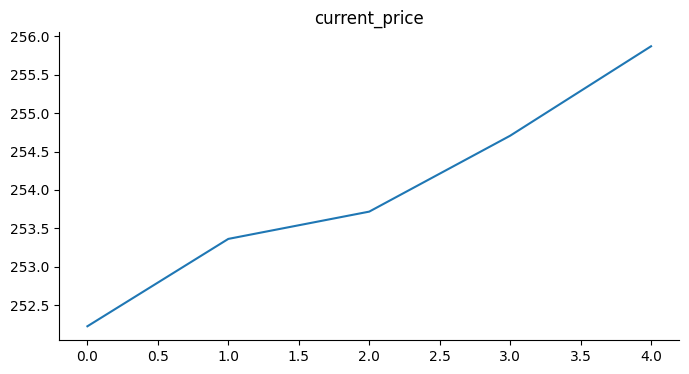

In [382]:
# @title current_price

from matplotlib import pyplot as plt
df_last_5_predictions['current_price'].plot(kind='line', figsize=(8, 4), title='current_price')
plt.gca().spines[['top', 'right']].set_visible(False)

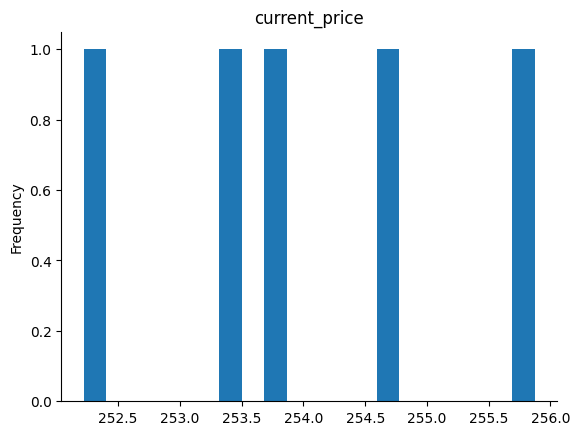

In [381]:
# @title current_price

from matplotlib import pyplot as plt
df_last_5_predictions['current_price'].plot(kind='hist', bins=20, title='current_price')
plt.gca().spines[['top', 'right',]].set_visible(False)